![Itq](img/LogoITQ.jpg)

**Programa 8 - Regresión Lineal Múltiple**

![Python](img/python_logo.png)

* *Nombre:* Judith Piedra
* *Fecha :* **29-09-2026**
* *Repositorio:* <a href= "https://github.com/MerakiDevJP/machine2_23092026nocturno.git"> Link del repositorio Github</a>
* https://github.com/MerakiDevJP/machine2_23092026nocturno.git

# Regresión Lineal Múltiple

In [1]:
import numpy as np #operaciones complejas entre matrices
from math import sqrt #raices cuadradas
from pprint import pprint #imprimir datos en consola
from sklearn import datasets, linear_model, metrics #librerías a usar
from sklearn.dummy import DummyRegressor # algoritmo de clasificación, compaa que algoritmo funciona mejor
from sklearn.model_selection import cross_validate, KFold, cross_val_predict, train_test_split, cross_val_score #modelo de selección, para validacion cruzada, dividir la base de datos en train y test
from sklearn import preprocessing # estandarizar los datos en base a media aritmética, normalizacion de cajon de 0 a 1
from sklearn.metrics import make_scorer, mean_squared_error #métricas MAE, error medio cuadrático
import matplotlib.pyplot as plt #gráficos

# solo se estandarizan los datos de entrada, los de salida no.

In [2]:
# Carga de datos
# datos = datasets.load_boston()
datos = datasets.fetch_california_housing()
# print(datos)

X = datos.data # datos de entrada
y = datos.target # datos de salida
print('Dimensiones de X: ', np.shape(X))
# print(y)

Dimensiones de X:  (20640, 8)


In [3]:
# Métricas de evaluación
metricas = {
'MAE': 'neg_mean_absolute_error', # métricas de evaluación absolutas
'RMSE': make_scorer(lambda y, y_pred:
                    sqrt(metrics.mean_squared_error(y, y_pred)),
                    greater_is_better=False),
'MAPE': make_scorer(lambda y, y_pred: # métricas de evaluación relativa
                    np.mean(np.abs((y- y_pred) / y)) * 100,
                    greater_is_better=False),
'R2': 'r2',}

In [4]:
# 1) Partición de datos externa
X_training, X_testing, y_training, y_testing = train_test_split(X, y, test_size=0.2, random_state=42)
print(np.shape(X_training))

(16512, 8)


In [5]:
# 2) Extracción de características (no se aplica en este base de datos)
# 3) Selección de atributos (no se ejecuta porque la base de datos viene limpia) 
# 4) Estandarización de los datos de entrenamiento
standardizer = preprocessing.StandardScaler()
stdr_trained = standardizer.fit(X_training)
X_stdr = stdr_trained.transform(X_training)

In [6]:
# 5) Construcción del algoritmo de aprendizaje.
reg = linear_model.LinearRegression(fit_intercept=True) # Wo 

In [7]:
# 5.1) Validación cruzada interna (5 bolsas)
# Extraer directamente resultados del error para cada bolsa, en lugar de las predicciones
cross_val_results = cross_validate(reg, X_stdr, y_training,
cv = KFold(n_splits=5, shuffle=True,random_state=42), scoring=metricas)
#print("cross_val_MAE: %0.4f +/- %0.4f" % (-cross_val_results.mean(), cross_val_results.std()))
pprint(cross_val_results)

{'fit_time': array([0.00250101, 0.00249839, 0.00200868, 0.00149989, 0.00150442]),
 'score_time': array([0.0015161 , 0.00099707, 0.00049829, 0.        , 0.00049973]),
 'test_MAE': array([-0.54071407, -0.52878981, -0.51274193, -0.53512422, -0.52793364]),
 'test_MAPE': array([-31.74769388, -31.65516613, -30.97054077, -32.61432353,
       -30.685065  ]),
 'test_R2': array([0.60970239, 0.60411343, 0.6354319 , 0.60076148, 0.60727452]),
 'test_RMSE': array([-0.73389779, -0.72516701, -0.69726867, -0.73337185, -0.71284225])}


In [8]:
# 5.2) Entrenamiento con todos los datos para obtener los coeficientes del modelo.
model = reg.fit(X_stdr, y_training)

# Obtención de los coeficientes del modelo.
w = model.coef_
print('Model coeficients: \n', w)

# Obtención del término independiente del modelo.
w_0 = model.intercept_
print('\nTérmino independiente: ', w_0)

Model coeficients: 
 [ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]

Término independiente:  2.071946937378619


In [9]:
 #---- PREDICCIÓN---- #

In [10]:
 # 6) Extracción de las características de test
# 7) Selección de los atributos de test
# 8) Estandarización de las característiacs de test
X_test_stdr = stdr_trained.transform(X_testing)

In [11]:
# 9) Predicción del conjunto de test
y_pred_test = model.predict(X_test_stdr)

In [12]:
# Cálculo de las métricas de evaluación.
MAE = metrics.mean_absolute_error(y_testing, y_pred_test)
MSE = metrics.mean_squared_error(y_testing, y_pred_test)
RMSE = np.sqrt(MSE)
MAPE = metrics.mean_absolute_percentage_error(y_testing, y_pred_test)
R2 = metrics.r2_score(y_testing, y_pred_test)
print('MAE: %.4f' % MAE)
print('MSE: %.4f' % MSE)
print('RMSE: %.4f' % RMSE)
print('MAPE: %.4f' % MAPE)
print('R2: %.4f' % R2)

MAE: 0.5332
MSE: 0.5559
RMSE: 0.7456
MAPE: 0.3195
R2: 0.5758


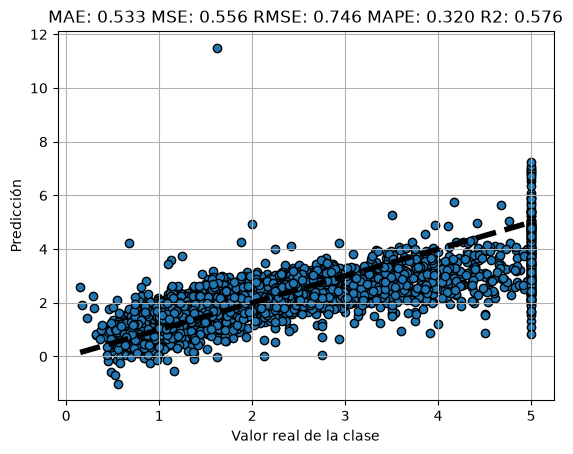

In [13]:
# Gráfica de realidad vs. predicción.
fig, ax = plt.subplots()
ax.scatter(y_testing, y_pred_test, edgecolors=(0, 0, 0))
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)
ax.set_xlabel('Valor real de la clase')
ax.set_ylabel('Predicción')
plt.title("MAE: %.3f MSE: %.3f RMSE: %.3f MAPE: %.3f R2: %.3f" %
(MAE,MSE,RMSE,MAPE,R2))
plt.grid()
plt.show()